## Step 1: Project Setup and Data Loading

In this step, I load the NASA C-MAPSS turbofan engine dataset and verify its structure before performing any analysis.

The FD001 subset is used because it represents:

- a single operating condition,
- a single fault mode,

making it suitable for building and validating an initial predictive maintenance pipeline before moving to more complex subsets such as FD002–FD004.

Setting a fixed random seed ensures reproducibility, meaning that experimental results remain consistent across runs.

After loading the data, I verify:

- dataset shapes
- engine counts
- column structure
- basic data integrity

This step is important because any structural mismatch or corrupted data would affect all downstream analysis and modeling steps.

The dataset is accessed through GitHub raw file links to improve reproducibility and portability across environments.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Reproducibility
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)



In [2]:
# Loading dataset
train_url = "https://raw.githubusercontent.com/sush9253/turbofan-predictive-maintenance/main/data/train_FD001.txt"
test_url = "https://raw.githubusercontent.com/sush9253/turbofan-predictive-maintenance/main/data/test_FD001.txt"
rul_url = "https://raw.githubusercontent.com/sush9253/turbofan-predictive-maintenance/main/data/RUL_FD001.txt"

train_df = pd.read_csv(train_url, sep=r"\s+", header=None)
test_df = pd.read_csv(test_url, sep=r"\s+", header=None)
rul_df = pd.read_csv(rul_url, sep=r"\s+", header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)


Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


In [3]:

# Column naming
cols = ["engine_id", "cycle_no"]
cols += [f"op_set{i}" for i in range(1, 4)]
cols += [f"sensor_{i}" for i in range(1, 22)]

train_df.columns = cols
test_df.columns = cols
rul_df.columns = ["RUL"]

# Engine counts
train_engines = train_df["engine_id"].nunique()
test_engines = test_df["engine_id"].nunique()

print("Training engines:", train_engines)
print("Test engines:", test_engines)

print("Total missing values:", train_df.isnull().sum().sum())

train_df.head()

Training engines: 100
Test engines: 100
Total missing values: 0


,engine_id,cycle_no,op_set1,op_set2,op_set3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Data Loading and Initial Verification


Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)

Training engines: 100
Test engines: 100

The dataset contains:

- engine_id
- cycle_no
- 3 operational settings
- 21 sensor readings

Each row represents one operational cycle of a turbofan engine.

The training dataset contains complete engine lifecycles until failure, which explains why it contains more rows than the test dataset. The test dataset contains truncated engine histories, while the separate RUL file provides the remaining useful life after the final observed test cycle.

The dataset structure appears consistent with the NASA C-MAPSS documentation:

- expected engine counts are present
- column counts match the documented schema
- no missing values are detected

This is also clearly a time-series problem because sensor behaviour evolves sequentially as engines degrade over time.

The next step is to investigate:

- engine lifetime variability
- sensor behaviour
- which features contain meaningful degradation signals

## Step 2: Data Understanding

In this step, I explore the dataset to better understand:

- feature distributions
- engine degradation behaviour
- operational characteristics
- sensor usefulness

This includes:

- checking data types and summary statistics
- validating missing values
- analyzing engine lifetimes
- identifying low-variance sensors
- exploring feature correlations
- studying sensor behaviour over time

This step is important because predictive maintenance performance depends heavily on understanding:

- how engines degrade
- which sensors carry meaningful information
- how degradation evolves across operational cycles

In [4]:

train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle_no   20631 non-null  int64  
 2   op_set1    20631 non-null  float64
 3   op_set2    20631 non-null  float64
 4   op_set3    20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [5]:

train_df.describe()


,engine_id,cycle_no,op_set1,op_set2,op_set3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [6]:

print("Total missing values:", train_df.isnull().sum().sum())

Total missing values: 0


### Basic Data Checks

The dataset contains:

20631 rows
26 columns

All columns contain non-null values, indicating that no missing data is present.

The dataset consists of:

- integer-based identifiers and cycle counters
- operational settings
- continuous sensor measurements

Sensor values operate on very different scales. For example:

- sensor_4 values are around 1400
- sensor_14 values exceed 8000
- while operational settings remain close to zero

This variation in scale is expected because different sensors measure different physical quantities such as:

- temperature
- pressure
- rotational speed
- airflow behaviour

Feature scaling will therefore become important for models such as Logistic Regression because:

- large-scale features can dominate optimization
- affect convergence behaviour
- distort coefficient interpretation

Tree-based models such as Random Forest and Gradient Boosting are much less sensitive to feature magnitude because they split based on feature thresholds rather than numerical scale.

At this stage, the dataset shows no immediate structural issues and is ready for deeper exploratory analysis.

In [7]:
# Engine lifetime analysis

engine_life = train_df.groupby("engine_id")["cycle_no"].max()

print(engine_life.describe())



count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle_no, dtype: float64


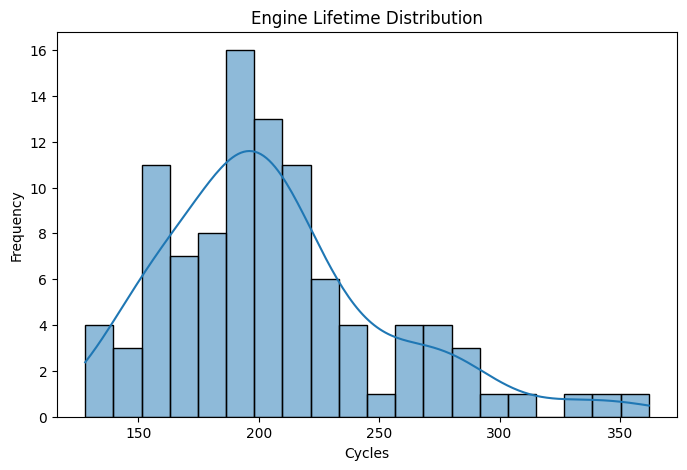

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(engine_life, bins=20, kde=True)
plt.title("Engine Lifetime Distribution")
plt.xlabel("Cycles")
plt.ylabel("Frequency")
plt.show()

## Engine Lifetime Analysis

Shortest lifetime: 128 cycles
Longest lifetime: 362 cycles
Mean lifetime: 206.31 cycles
Median lifetime: 199 cycles

Most engines fail around:

150–250 cycles

The lifetime distribution is slightly right-skewed because a small number of engines survive substantially longer than average.

I initially expected engine lifetimes to be more consistent, but the large variation between:

128
and
362 cycles

shows that engines degrade at different rates.

This is important because the model must generalize across multiple degradation trajectories rather than memorizing a fixed failure timeline.

The relatively wide spread in engine lifetimes also means that features related to cycle position must be handled carefully. Features that implicitly reveal how close an engine is to its maximum lifetime could unintentionally leak failure information into the model.

Since degradation occurs gradually over time, this further supports the use of:

- rolling statistics
- temporal trends
- sequential feature engineering

instead of relying only on single-cycle sensor snapshots.

In [9]:
# Sensor variance analysis

sensor_cols = [col for col in train_df.columns if "sensor" in col]

sensor_variance = train_df[sensor_cols].var().sort_values()

sensor_variance.head(10)


,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,2.422479e-28
sensor_10,2.172333e-25
sensor_5,1.152399e-23
sensor_1,4.273435e-21
sensor_6,1.929279e-06
sensor_15,1.406628e-03
sensor_8,5.038938e-03
sensor_13,5.172330e-03


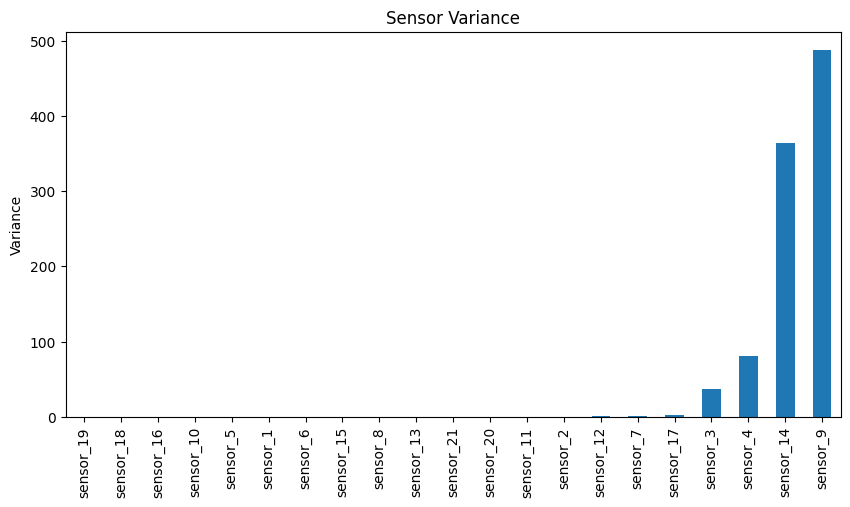

In [10]:

plt.figure(figsize=(10,5))
sensor_variance.plot(kind='bar')
plt.title("Sensor Variance")
plt.ylabel("Variance")
plt.show()

low_var_sensors =sensor_variance[sensor_variance < 0.01].index.tolist()

train_df = train_df.drop(columns=low_var_sensors)
test_df = test_df.drop(columns=low_var_sensors)

## Sensor Variance Analysis

A variance threshold of 0.01 is used to identify sensors that remain nearly constant across engines and operational cycles.

Sensors removed:

sensor_19
sensor_18
sensor_16
sensor_10
sensor_5
sensor_1
sensor_6
sensor_15
sensor_8
sensor_13

These sensors exhibit extremely low variance, meaning they contribute little meaningful information for predictive modeling.

Sensors with:

- zero variance provide no predictive signal
- while near-constant sensors contribute minimal information  may introduce unnecessary noise.

Removing these features helps:

- reduce feature redundancy,
- simplify modeling
- focus learning on sensors that better capture degradation behaviour.

Although sklearn’s VarianceThreshold could automate this process, I performed the analysis manually first in order to understand:

- which sensors were nearly constant
- whether their removal made sense both statistically and operationally.

Remaining sensors: 11

In [11]:
# Operational settings

train_df[['op_set1','op_set2','op_set3']].var()


,0
op_set1,4.784340e-06
op_set2,8.588541e-08
op_set3,0.000000e+00


In [12]:

train_df = train_df.drop(columns=['op_set1','op_set2','op_set3'])
test_df = test_df.drop(columns=['op_set1','op_set2','op_set3'])

## Operational Settings Analysis

All three operational settings show extremely low variance, with:

op_set3 being completely constant.

This confirms that the FD001 subset represents:

- a single operating condition,
- a single fault mode.

Because these operational settings do not meaningfully vary across engines or cycles, they provide little useful information for predicting engine degradation.

Therefore, all three operational settings are removed.

This behaviour is specific to the FD001 subset. In more complex datasets such as:

- FD002
- FD003
- FD004

operational settings vary substantially and become much more important for modeling engine behaviour under multiple conditions.

In [13]:
# Correlation analysis

corr_features = train_df.drop(columns=["engine_id", "cycle_no"])

corr_matrix = corr_features.corr()

corr_matrix

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_14,sensor_17,sensor_20,sensor_21
sensor_2,1.000000,0.602610,0.714949,-0.702136,0.273764,0.740020,-0.724578,0.179752,0.629886,-0.661841,-0.668050
sensor_3,0.602610,1.000000,0.678413,-0.664595,0.322964,0.695900,-0.680307,0.237137,0.600017,-0.625941,-0.633901
sensor_4,0.714949,0.678413,1.000000,-0.793130,0.297429,0.830136,-0.815591,0.190748,0.703499,-0.748067,-0.745193
sensor_7,-0.702136,-0.664595,-0.793130,1.000000,-0.217835,-0.822805,0.812713,-0.110053,-0.692893,0.736163,0.737447
sensor_9,0.273764,0.322964,0.297429,-0.217835,1.000000,0.274591,-0.210238,0.963157,0.337110,-0.285280,-0.292795
sensor_11,0.740020,0.695900,0.830136,-0.822805,0.274591,1.000000,-0.846884,0.163408,0.722296,-0.771510,-0.772554
sensor_12,-0.724578,-0.680307,-0.815591,0.812713,-0.210238,-0.846884,1.000000,-0.098141,-0.703485,0.751943,0.756263
sensor_14,0.179752,0.237137,0.190748,-0.110053,0.963157,0.163408,-0.098141,1.000000,0.246621,-0.187364,-0.192415
sensor_17,0.629886,0.600017,0.703499,-0.692893,0.337110,0.722296,-0.703485,0.246621,1.000000,-0.651021,-0.658710
sensor_20,-0.661841,-0.625941,-0.748067,0.736163,-0.285280,-0.771510,0.751943,-0.187364,-0.651021,1.000000,0.693480


In [14]:
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

high_corr

[('sensor_11', 'sensor_4', np.float64(0.8301356963159815)),
 ('sensor_11', 'sensor_7', np.float64(-0.8228050249957691)),
 ('sensor_12', 'sensor_4', np.float64(-0.815590516105214)),
 ('sensor_12', 'sensor_7', np.float64(0.812712601325414)),
 ('sensor_12', 'sensor_11', np.float64(-0.8468835930051095)),
 ('sensor_14', 'sensor_9', np.float64(0.9631566003059776))]

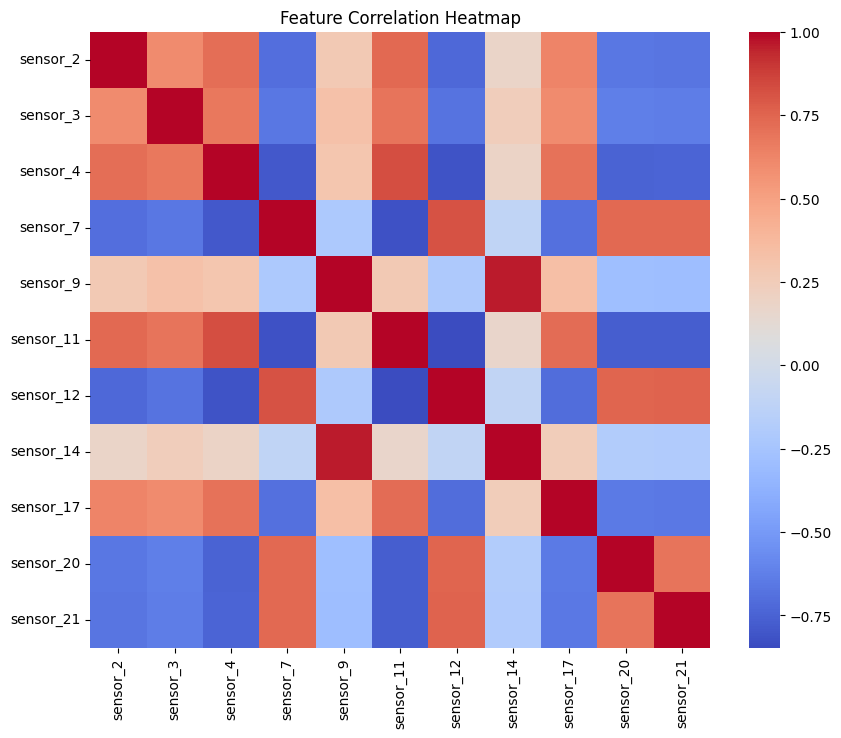

In [15]:

plt.figure(figsize=(10,8))
sns.heatmap(corr_features.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


## Correlation Analysis

Only one pair shows very high correlation above 0.85:

sensor_9 and sensor_14 → 0.963

Other moderately high correlations include:

- sensor_11 and sensor_4 → 0.83
- sensor_11 and sensor_7 → -0.823
- sensor_12 and sensor_4 → -0.816
- sensor_12 and sensor_7 → 0.813
- sensor_12 and sensor_11 → -0.847

I use 0.8 as the threshold for strong correlation because values above this level often indicate substantial overlap in information content.

Although some feature pairs are strongly correlated, I decided not to remove them at this stage.

For Logistic Regression, high correlation can lead to multicollinearity and unstable coefficients. However, tree-based models such as Random Forest and Gradient Boosting are much less sensitive to correlated features.

Also, even correlated sensors may still capture different aspects of engine degradation.

At this stage, I keep all features and will revisit feature selection later if needed.

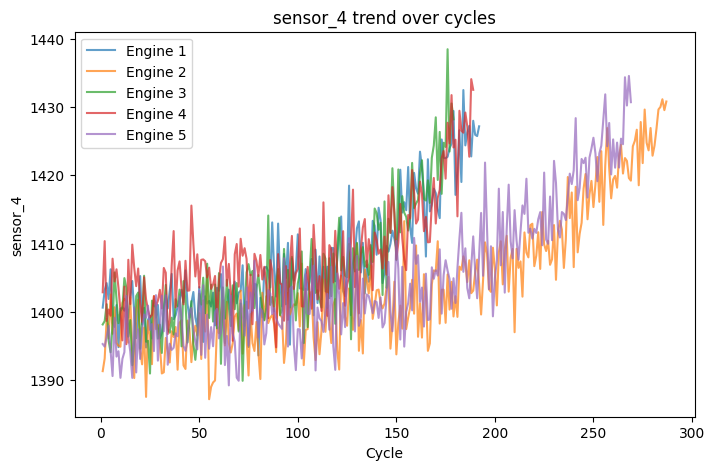

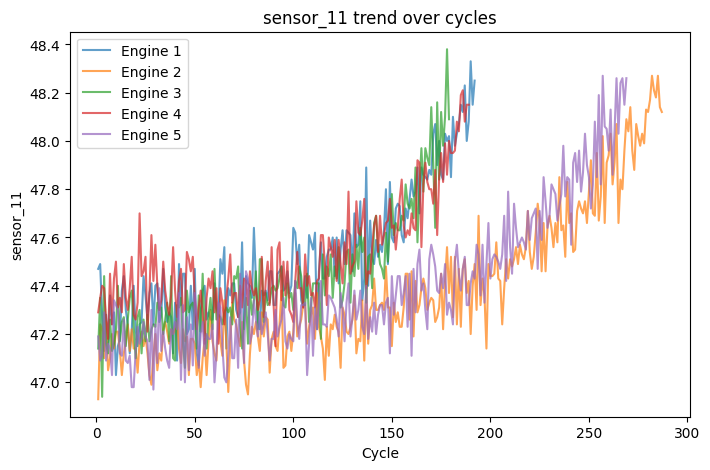

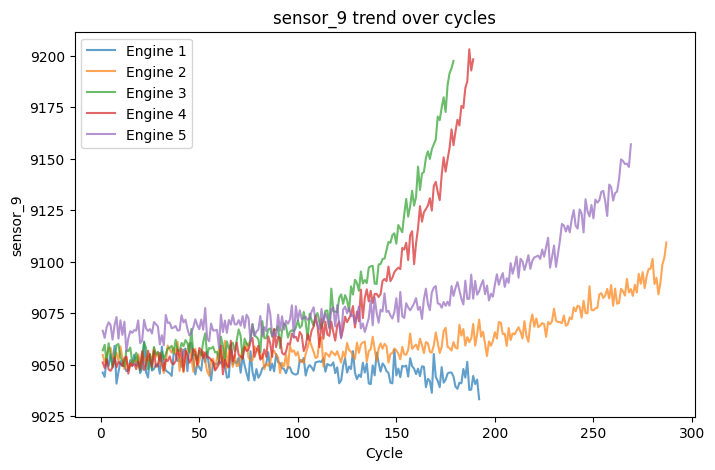

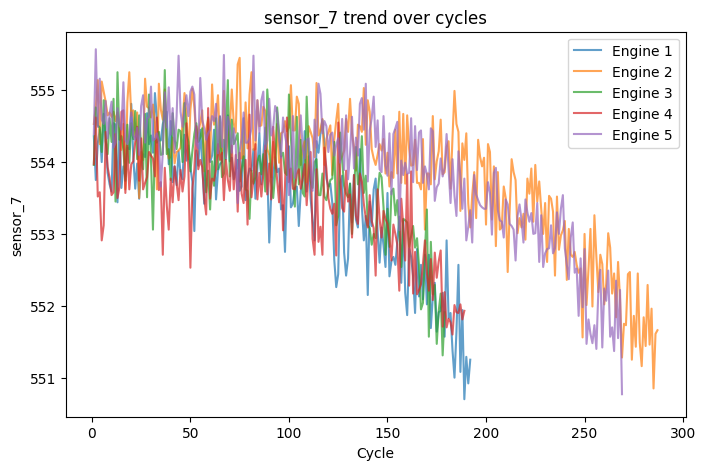

In [16]:
# Sensor trend analysis

engines = train_df["engine_id"].unique()[:5]

sensors_to_plot = ["sensor_4", "sensor_11", "sensor_9", "sensor_7"]

for sensor in sensors_to_plot:
    plt.figure(figsize=(8,5))
    for eng in engines:
        temp = train_df[train_df["engine_id"] == eng]
        plt.plot(temp["cycle_no"], temp[sensor],alpha=0.7,label=f"Engine {eng}")
    plt.title(f"{sensor} trend over cycles")
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.legend()
    plt.show()

## Sensor Trend Analysis

- sensor_4 (T50 – temperature at Low Pressure Turbine outlet)
→ generally increases over cycles
→ likely due to reduced compressor efficiency causing higher downstream temperature
- sensor_11 (NRc – corrected core speed)
→ increases over time
→ the engine compensates for efficiency loss by increasing core speed
- sensor_7 (Ps30 – pressure at High Pressure Compressor outlet)
→ gradually decreases
→ suggesting the compressor becomes less effective at maintaining pressure
- sensor_9 (fan speed)
→ shows inconsistent behaviour across engines

I expected all sensors to show similar degradation trends, but sensor_9 behaves differently across engines. This suggests that not all engines degrade in exactly the same way.

Some sensors may also be more sensitive to engine-specific operational behaviour or noise rather than representing a universal degradation signal.

Overall, degradation becomes much more noticeable after around 100–120 cycles.

This confirms that degradation is a gradual process rather than a sudden failure event.

Because some sensors appear noisy or inconsistent over short periods, rolling statistics will likely help smooth short-term fluctuations and capture longer degradation trends more effectively.

## Step 3: Remaining Useful Life (RUL) and Target Variable

In this step, I calculate the Remaining Useful Life (RUL) for each engine and convert it into a binary classification problem.

RUL represents the number of cycles remaining before an engine fails.

Since the training dataset contains full engine lifecycles until failure, RUL can be calculated directly.

I convert the problem into binary classification because the real objective in predictive maintenance is usually operational decision-making:

- identifying engines approaching failure
- rather than predicting the exact number of remaining cycles.

The classification target is defined as:

0 → Healthy engine
1 → Engine likely to fail within 30 cycles

I use a 30-cycle failure window because it provides enough time for maintenance planning while still focusing on engines approaching meaningful degradation.

This step is important because it defines the prediction target and determines how the model interprets engine health.

In [17]:
# Calculate max cycle per engine
max_cycle = train_df.groupby('engine_id')['cycle_no'].max().reset_index()

# Merge with training data
train_df = train_df.merge(
    max_cycle.rename(columns={'cycle_no': 'max_cycle'}),
    on='engine_id'
)

# Calculate RUL
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle_no']

train_df[['engine_id','cycle_no','max_cycle','RUL']].tail()

,engine_id,cycle_no,max_cycle,RUL
20626,100,196,200,4
20627,100,197,200,3
20628,100,198,200,2
20629,100,199,200,1
20630,100,200,200,0


## RUL Calculation (Training Data)

RUL is calculated as:

RUL = max_cycle − current_cycle

This means:
- At the start of engine life → RUL is high  
- At the final cycle → RUL becomes 0  

As cycle number increases, RUL decreases gradually, reflecting engine degradation over time.

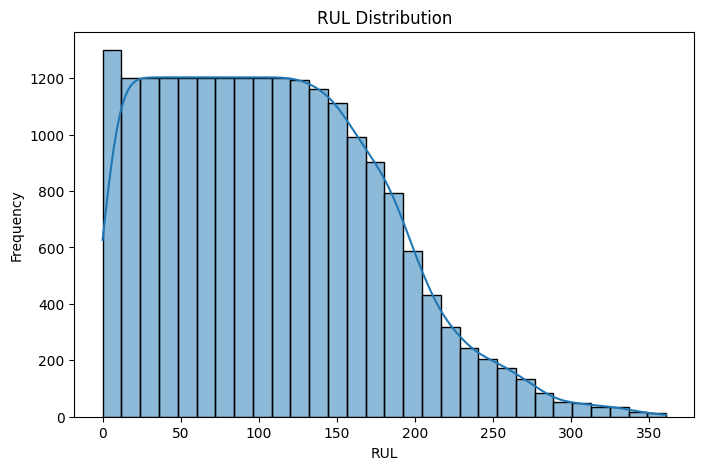

In [18]:
# RUL distribution
plt.figure(figsize=(8,5))
sns.histplot(train_df['RUL'],bins=30, kde=True)
plt.title("RUL Distribution")
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.show()

## RUL Distribution

The RUL distribution is right-skewed, with many observations at higher RUL values and fewer observations close to failure.

This makes sense because engines spend most of their operational life in a relatively healthy state, while the actual degradation period near failure is much shorter.

I expected more observations near failure, but the distribution shows that failure points are relatively rare.

This naturally creates class imbalance when converting RUL into a binary classification target.

In [19]:
# Binary target creation

train_df['failure'] = (train_df['RUL'] <= 30).astype(int)

train_dist = train_df['failure'].value_counts(normalize=True) * 100
train_dist

,proportion
failure,
0,84.974068
1,15.025932


## Binary Target Creation

I converted RUL into a binary target:

failure = 1 if RUL ≤ 30
failure = 0 if RUL > 30

Training distribution:

Healthy → 84.97%
Failure → 15.03%

This shows a clear class imbalance, where failure cases are much less common than healthy observations.

A model predicting every engine as healthy would still achieve around 85% accuracy, which would be misleading.

Since missing a failing engine is much more critical than a false alarm, recall becomes the most important evaluation metric.

A lower threshold such as 10 cycles would focus only on imminent failures, while a larger threshold such as 50 cycles would provide earlier warnings but also increase ambiguity between healthy and degrading engines.

In [20]:
# Test data RUL and target
# Rename column
rul_df.columns = ['RUL_given']

# Get last cycle per engine
test_max = test_df.groupby('engine_id')['cycle_no'].max().reset_index()
test_max.columns = ['engine_id', 'max_cycle_test']

# Add given RUL
test_max['RUL_at_cutoff'] = rul_df['RUL_given'].values

# Merge
test_df = test_df.merge(test_max, on='engine_id')

# Compute full RUL
test_df['RUL'] = test_df['RUL_at_cutoff'] + (test_df['max_cycle_test'] - test_df['cycle_no'])

# Create failure label
test_df['failure'] = (test_df['RUL'] <= 30).astype(int)

test_dist = test_df['failure'].value_counts(normalize=True) * 100
test_dist

,proportion
failure,
0,97.464875
1,2.535125


## Test Data RUL and Class Distribution

Training distribution:

- Healthy → 84.97%
- Failure → 15.03%

Test distribution:

- Healthy → 97.46%
- Failure → 2.54%

This shows a major distribution shift between the training and test datasets.

The failure rate in the test set is almost 6× lower than in the training data.

This means the model will be evaluated on a much more imbalanced dataset than it was trained on.

I expected some imbalance, but the difference between train and test distributions is larger than expected.

This is important because:

- a threshold optimized on training data may not behave the same way on test data,
- predicted probabilities may require recalibration in deployment environments with different failure rates.

This also reflects a real-world predictive maintenance challenge:
models are often trained on historical failure-rich datasets but deployed in environments where actual failures are relatively rare.

## Step 4: Feature Engineering

Each row in the dataset represents a single snapshot of engine behaviour at a given cycle. However, engine degradation is a gradual process that develops over time.

A raw sensor value alone does not provide enough context. For example, a temperature value of 1400 does not indicate whether the engine is healthy or degrading unless we know how that value has changed across previous cycles.

To capture this time-dependent behaviour, I create rolling features such as:

- Rolling mean → captures degradation trend
- Rolling standard deviation → captures variability and instability
- Rate of change → captures short-term sensor movement

I first build a baseline model using only raw sensor values. This helps verify whether feature engineering actually improves performance instead of adding unnecessary complexity.

Because predictive maintenance is inherently temporal, I expect rolling features to perform better than raw single-cycle snapshots.

In [21]:
# Baseline model without features
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import recall_score, f1_score

# Raw sensor columns
sensor_cols = [col for col in train_df.columns if "sensor" in col]

# Split by engine_id
engine_ids = train_df['engine_id'].unique()

train_ids, val_ids = train_test_split(engine_ids, test_size=0.2, random_state=SEED)

train_data = train_df[train_df['engine_id'].isin(train_ids)]
val_data = train_df[train_df['engine_id'].isin(val_ids)]

# Features
X_train = train_data[sensor_cols]
y_train = train_data['failure']

X_val = val_data[sensor_cols]
y_val = val_data['failure']

# Model
gb_model = GradientBoostingClassifier(random_state=SEED)
gb_model.fit(X_train, y_train)

# Predictions
y_val_pred = gb_model.predict(X_val)

# Metrics
baseline_recall = recall_score(y_val, y_val_pred)
baseline_f1 = f1_score(y_val, y_val_pred)

print("Baseline Recall:", baseline_recall)
print("Baseline F1:", baseline_f1)

Baseline Recall: 0.8693548387096774
Baseline F1: 0.8778501628664495


## Baseline Model (Raw Sensors)

Baseline recall: 0.869

Baseline F1: 0.878  

The model using only raw sensor values already achieves strong performance.

This suggests that the selected sensors contain meaningful information about engine degradation, even without additional feature engineering.

This baseline will serve as a reference to evaluate whether engineered features actually improve performance.

In [22]:
# Rolling features for TRAIN

for window in [5, 10, 20]:
    for col in sensor_cols:
        train_df[f'{col}_rollmean_{window}'] = train_df.groupby('engine_id')[col]\
            .transform(lambda x: x.rolling(window, min_periods=1).mean())

        train_df[f'{col}_rollstd_{window}'] = train_df.groupby('engine_id')[col]\
            .transform(lambda x: x.rolling(window, min_periods=1).std())

# Rate of change
for col in sensor_cols:
    train_df[f'{col}_roc'] = train_df.groupby('engine_id')[col].diff().fillna(0)

train_df.fillna(0, inplace=True)

In [23]:
# Rolling features for TEST

for window in [5, 10, 20]:
    for col in sensor_cols:
        test_df[f'{col}_rollmean_{window}'] = test_df.groupby('engine_id')[col]\
            .transform(lambda x: x.rolling(window, min_periods=1).mean())

        test_df[f'{col}_rollstd_{window}'] = test_df.groupby('engine_id')[col]\
            .transform(lambda x: x.rolling(window, min_periods=1).std())

for col in sensor_cols:
    test_df[f'{col}_roc'] = test_df.groupby('engine_id')[col].diff().fillna(0)

test_df.fillna(0, inplace=True)

In [25]:


engine_ids = train_df['engine_id'].unique()

train_ids, val_ids = train_test_split(engine_ids, test_size=0.2, random_state=42)

train_data = train_df[train_df['engine_id'].isin(train_ids)]
val_data = train_df[train_df['engine_id'].isin(val_ids)]

print("Train shape:", train_data.shape)
print("Val shape:", val_data.shape)

Train shape: (16561, 93)
Val shape: (4070, 93)


In [26]:
features_w5 = []

for col in sensor_cols:
    features_w5.append(f"{col}_rollmean_5")
    features_w5.append(f"{col}_rollstd_5")
    features_w5.append(f"{col}_roc")


X_train_w5 = train_data[features_w5]
X_val_w5 = val_data[features_w5]

gb_w5 = GradientBoostingClassifier(random_state=SEED)
gb_w5.fit(X_train_w5, train_data['failure'])

y_pred_w5 = gb_w5.predict(X_val_w5)

recall_w5 = recall_score(val_data['failure'], y_pred_w5)
f1_w5 = f1_score(val_data['failure'], y_pred_w5)

print("W5 Recall:", recall_w5)
print("W5 F1:", f1_w5)

W5 Recall: 0.8661290322580645
W5 F1: 0.8927680798004988


In [27]:
features_all = []

for col in sensor_cols:
    for w in [5, 10, 20]:
        features_all.append(f"{col}_rollmean_{w}")
        features_all.append(f"{col}_rollstd_{w}")
    features_all.append(f"{col}_roc")

X_train_all = train_data[features_all]
X_val_all = val_data[features_all]

gb_all = GradientBoostingClassifier(random_state=SEED)
gb_all.fit(X_train_all, train_data['failure'])

y_pred_all = gb_all.predict(X_val_all)

recall_all = recall_score(val_data['failure'], y_pred_all)
f1_all = f1_score(val_data['failure'], y_pred_all)

print("ALL Recall:", recall_all)
print("ALL F1:", f1_all)

ALL Recall: 0.8774193548387097
ALL F1: 0.9096989966555183


In [29]:
comparison_df = pd.DataFrame({
    "Feature Set": [
        "Raw Sensors",
        "Rolling (w=5)",
        "Rolling (5,10,20)"
    ],
    "Recall": [
        baseline_recall,
        recall_w5,
        recall_all
    ],
    "F1 Score": [
        baseline_f1,
        f1_w5,
        f1_all
    ]
})

comparison_df

,Feature Set,Recall,F1 Score
0,Raw Sensors,0.869355,0.877850
1,Rolling (w=5),0.866129,0.892768
2,"Rolling (5,10,20)",0.877419,0.909699


## Feature Engineering Comparison

Raw Sensors:
- Recall: 0.869  
- F1 Score: 0.878  

Rolling (window=5):
- Recall: 0.866  
- F1 Score: 0.893  

Rolling (5,10,20):
- Recall: 0.877  
- F1 Score: 0.91

Best feature set: Rolling (5,10,20)  

Improvement over baseline: 0.8 percentage points in recall

I expected feature engineering to improve performance, but the rolling window of 5 cycles did not help much. This suggests that short-term windows capture small fluctuations rather than meaningful degradation patterns.

However, using multiple window sizes (5, 10, 20) improved performance, indicating that medium- and long-term trends are more important for predicting failure.

This confirms that engine degradation is a gradual process, and models benefit more from capturing long-term patterns rather than short-term noise.

## Step 5: Train-Validation Split and Feature Scaling

In this step, I split the dataset into training and validation sets and apply feature scaling where required.

The split is done using engine_id to ensure that all cycles from a given engine are contained entirely within either the training or validation set.

This is important because engine sensor trajectories evolve gradually over time. If I randomly split rows, the model could see cycles from the same engine in both training and validation data, leading to overly optimistic performance.

Using unseen engines for validation better simulates a real-world predictive maintenance scenario.

Feature scaling is applied only for models like Logistic Regression, which are sensitive to feature magnitudes.

In [30]:


# Unique engine IDs
engine_ids = train_df['engine_id'].unique()

# Split engines (NOT rows)
train_ids, val_ids = train_test_split(engine_ids, test_size=0.2, random_state=SEED)

# Create datasets
train_data = train_df[train_df['engine_id'].isin(train_ids)]
val_data = train_df[train_df['engine_id'].isin(val_ids)]

print("Train engines:", len(train_ids))
print("Validation engines:", len(val_ids))
print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)

Train engines: 80
Validation engines: 20
Train shape: (16561, 93)
Validation shape: (4070, 93)


In [31]:
# Using clean feature

X_train = train_data[features_all]
y_train = train_data['failure']

X_val = val_data[features_all]
y_val = val_data['failure']

# Test set
X_test = test_df[features_all]

In [33]:
print("Train failure rate:")
print(y_train.value_counts(normalize=True))

print("\nValidation failure rate:")
print(y_val.value_counts(normalize=True))

Train failure rate:
failure
0    0.850251
1    0.149749
Name: proportion, dtype: float64

Validation failure rate:
failure
0    0.847666
1    0.152334
Name: proportion, dtype: float64


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data using same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Train-Validation Split and Feature Scaling

The dataset was split based on engine_id, ensuring that all cycles from a given engine are present in only one set.

This prevents data leakage, as splitting randomly by rows would allow the model to see partial information from the same engine in both training and validation sets.

This setup simulates a real-world scenario where the model is applied to completely unseen engines.

Feature scaling was applied using StandardScaler for Logistic Regression.

The scaler was fitted only on the training data and then applied to validation and test data:

- X_train_scaled = scaler.fit_transform(X_train)  
- X_val_scaled = scaler.transform(X_val)  
- X_test_scaled = scaler.transform(X_test)  

This ensures that no information from validation or test data is used during training, avoiding data leakage.

Tree-based models such as Random Forest and Gradient Boosting do not require scaling, as they are based on feature splits and are not affected by feature magnitudes.

## Step 6: Logistic Regression Baseline

In this step, I train Logistic Regression as a baseline model.

Logistic Regression is a simple and interpretable model that provides well-calibrated probabilities. It serves as a strong baseline to evaluate whether more complex models are necessary.

If Logistic Regression performs well, it indicates that the features capture the underlying patterns effectively. If more complex models perform significantly better, it suggests the presence of non-linear relationships.

Because the dataset is imbalanced and missing failures is costly, I focus mainly on:

- recall
- precision-recall tradeoff
- confusion matrix behaviour.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Default Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)

lr_model.fit(X_train_scaled, y_train)

y_val_pred_lr = lr_model.predict(X_val_scaled)
y_val_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Metrics
lr_acc = accuracy_score(y_val, y_val_pred_lr)
lr_prec = precision_score(y_val, y_val_pred_lr)
lr_rec = recall_score(y_val, y_val_pred_lr)
lr_f1 = f1_score(y_val, y_val_pred_lr)
lr_auc = roc_auc_score(y_val, y_val_proba_lr)

print("LR Default Metrics:")
print("Accuracy:", lr_acc)
print("Precision:", lr_prec)
print("Recall:", lr_rec)
print("F1:", lr_f1)
print("ROC-AUC:", lr_auc)

LR Default Metrics:
Accuracy: 0.9761670761670762
Precision: 0.9351081530782029
Recall: 0.9064516129032258
F1: 0.9205569205569205
ROC-AUC: 0.9966839644693781


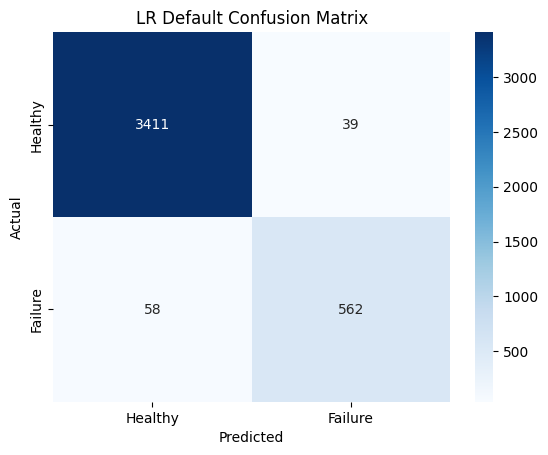

In [37]:
cm = confusion_matrix(y_val, y_val_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Healthy', 'Failure'],yticklabels=['Healthy', 'Failure'])
plt.title("LR Default Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
# Logistic Regression with class_weight

lr_balanced = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

lr_balanced.fit(X_train_scaled, y_train)

y_val_pred_lr_bal = lr_balanced.predict(X_val_scaled)
y_val_proba_lr_bal = lr_balanced.predict_proba(X_val_scaled)[:, 1]

# Metrics
lrb_acc = accuracy_score(y_val, y_val_pred_lr_bal)
lrb_prec = precision_score(y_val, y_val_pred_lr_bal)
lrb_rec = recall_score(y_val, y_val_pred_lr_bal)
lrb_f1 = f1_score(y_val, y_val_pred_lr_bal)
lrb_auc = roc_auc_score(y_val, y_val_proba_lr_bal)

print("LR Balanced Metrics:")
print("Accuracy:", lrb_acc)
print("Precision:", lrb_prec)
print("Recall:", lrb_rec)
print("F1:", lrb_f1)
print("ROC-AUC:", lrb_auc)

LR Balanced Metrics:
Accuracy: 0.9670761670761671
Precision: 0.8319672131147541
Recall: 0.9822580645161291
F1: 0.900887573964497
ROC-AUC: 0.9961547452080411


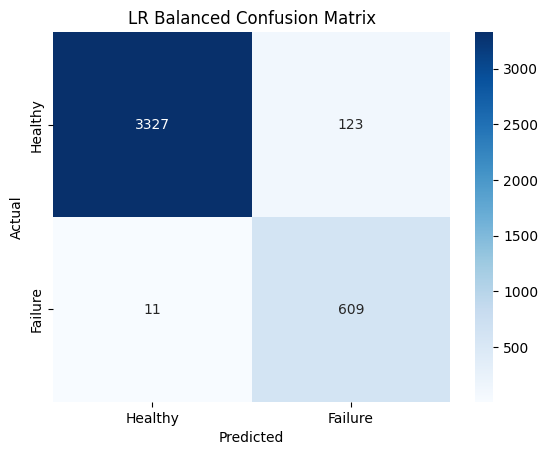

In [39]:
cm_bal = confusion_matrix(y_val, y_val_pred_lr_bal)

sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Blues',xticklabels=['Healthy', 'Failure'],yticklabels=['Healthy', 'Failure'])
plt.title("LR Balanced Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
lr_comparison = pd.DataFrame({
    "Model": ["LR Default", "LR Balanced"],
    "Precision": [lr_prec, lrb_prec],
    "Recall": [lr_rec, lrb_rec],
    "F1 Score": [lr_f1, lrb_f1],
    "ROC-AUC": [lr_auc,lrb_auc]
})

lr_comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,LR Default,0.935108,0.906452,0.920557,0.996684
1,LR Balanced,0.831967,0.982258,0.900888,0.996155


## Logistic Regression Baseline

LR (default):
- Precision: 0.935  
- Recall: 0.906  
- F1 Score: 0.921  

LR (balanced):
- Precision: 0.832  
- Recall: 0.982  
- F1 Score: 0.901  

class_weight='balanced' improved recall from 0.906 to 0.982.

Precision changed from 0.935 to 0.832.

This trade-off is acceptable because missing a failing engine (false negative) is much more costly than a false alarm. In aviation, a missed failure can lead to severe consequences, whereas a false alarm only results in additional inspection.

### Confusion Matrix Interpretation

Default LR:
- False Negatives: 58  
- True Positives: 562  

Balanced LR:
- False Negatives: 11  
- True Positives: 609  

The balanced model significantly reduces missed failures from 58 to 11, which directly improves recall.

### Observation

The balanced model improved recall significantly. The decrease in precision was expected, as the model prioritizes detecting failures over avoiding false alarms.

Overall, the balanced model is more suitable for this problem due to the higher importance of recall.

## Step 7: Ensemble Models

In this step, I train ensemble models — Random Forest and Gradient Boosting — and compare them with Logistic Regression.

Ensemble models are more powerful than linear models because they can capture non-linear relationships between features.

Random Forest builds multiple independent trees and averages their predictions, reducing overfitting.

Gradient Boosting builds trees sequentially, where each tree corrects the errors of the previous one, making it more powerful but also more sensitive to overfitting.

All models are evaluated using the same train-validation split to ensure a fair comparison.

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report,roc_auc_score

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)

y_val_proba_rf = (rf_model.predict_proba(X_val)[:, 1])

# Metrics
rf_prec = precision_score(y_val, y_val_pred_rf)
rf_rec = recall_score(y_val, y_val_pred_rf)
rf_f1 = f1_score(y_val, y_val_pred_rf)
rf_auc = roc_auc_score(y_val,y_val_proba_rf)

print("Random Forest Metrics:")
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1:", rf_f1)
print("ROC-AUC:", rf_auc)

print("\nRandom Forest Classification Report:")
print(classification_report(y_val, y_val_pred_rf))

Random Forest Metrics:
Precision: 0.95
Recall: 0.8580645161290322
F1: 0.9016949152542373
ROC-AUC: 0.993811126694717

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3450
           1       0.95      0.86      0.90       620

    accuracy                           0.97      4070
   macro avg       0.96      0.92      0.94      4070
weighted avg       0.97      0.97      0.97      4070



In [44]:


# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=SEED
)

gb_model.fit(X_train, y_train)

y_val_pred_gb = gb_model.predict(X_val)

y_val_proba_gb = (gb_model.predict_proba(X_val)[:, 1])


# Metrics
gb_prec = precision_score(y_val, y_val_pred_gb)
gb_rec = recall_score(y_val, y_val_pred_gb)
gb_f1 = f1_score(y_val, y_val_pred_gb)
gb_auc = roc_auc_score(y_val,y_val_proba_gb)

print("Gradient Boosting Metrics:")
print("Precision:", gb_prec)
print("Recall:", gb_rec)
print("F1:", gb_f1)
print("ROC-AUC:", gb_auc)

print("\nGradient Boosting Classification Report:")
print(classification_report(y_val, y_val_pred_gb))

Gradient Boosting Metrics:
Precision: 0.9474605954465849
Recall: 0.8725806451612903
F1: 0.90848026868178
ROC-AUC: 0.9945310892940626

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3450
           1       0.95      0.87      0.91       620

    accuracy                           0.97      4070
   macro avg       0.96      0.93      0.95      4070
weighted avg       0.97      0.97      0.97      4070



In [46]:
comparison_all_models = pd.DataFrame({

    "Model": [
        "LR Default",
        "LR Balanced",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision": [
        lr_prec,
        lrb_prec,
        rf_prec,
        gb_prec
    ],

    "Recall": [
        lr_rec,
        lrb_rec,
        rf_rec,
        gb_rec
    ],

    "F1 Score": [
        lr_f1,
        lrb_f1,
        rf_f1,
        gb_f1
    ],

    "ROC-AUC": [
        lr_auc,
        lrb_auc,
        rf_auc,
        gb_auc
    ]
})

comparison_all_models

,Model,Precision,Recall,F1 Score,ROC-AUC
0,LR Default,0.935108,0.906452,0.920557,0.996684
1,LR Balanced,0.831967,0.982258,0.900888,0.996155
2,Random Forest,0.950000,0.858065,0.901695,0.993811
3,Gradient Boosting,0.947461,0.872581,0.908480,0.994531


## Ensemble Model Comparison

I trained and evaluated Random Forest and Gradient Boosting models using the same train-validation split and compared them with Logistic Regression.

LR Default:
- Precision: 0.935  
- Recall: 0.906  
- F1 Score: 0.921  

LR Balanced:
- Precision: 0.832  
- Recall: 0.982  
- F1 Score: 0.901  

Random Forest:
- Precision: 0.950  
- Recall: 0.858  
- F1 Score: 0.902  

Gradient Boosting:
- Precision: 0.947  
- Recall: 0.873  
- F1 Score: 0.908  

### Observations

- Logistic Regression (balanced) achieved the highest recall of 0.982, making it the best at detecting failing engines.
- Random Forest achieved high precision (0.950) but had lower recall (0.858), meaning it missed more failures.
- Gradient Boosting provided a better balance than Random Forest, with higher recall (0.873) and F1 score (0.908).

I expected ensemble models to outperform Logistic Regression due to their ability to capture non-linear relationships. However, Logistic Regression with class weighting still achieved the highest recall.

This suggests that the engineered features are strong enough that even a linear model can effectively detect degradation patterns.



- If the goal is to maximize recall, Logistic Regression (balanced) is the best choice.
- If the goal is balanced performance, Gradient Boosting is the better choice.
- Random Forest is more conservative, prioritizing precision but missing more failures.

At this stage, I am not selecting the final model yet, as further steps such as cross-validation and threshold tuning are required.

## Step 8: Cross-Validation

To ensure that model performance is not dependent on a single train-validation split, I perform cross-validation.

Cross-validation trains and evaluates the model multiple times on different subsets of the data, providing a more reliable estimate of performance.

I use StratifiedKFold so that each fold maintains the same class distribution (~85% healthy and ~15% failure), which is important due to class imbalance.

Recall is used as the evaluation metric because missing a failure is more critical than a false alarm.

In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score




cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Logistic Regression
lr_cv = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

lr_scores = cross_val_score(
    lr_cv,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='recall'
)

# Random Forest
rf_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1
)

rf_scores = cross_val_score(
    rf_cv,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)

# Gradient Boosting
gb_cv = GradientBoostingClassifier(
    n_estimators=200,
    random_state=SEED
)

gb_scores = cross_val_score(
    gb_cv,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)

print("LR (balanced):", lr_scores.mean(), "+/-", lr_scores.std())
print("RF:", rf_scores.mean(), "+/-", rf_scores.std())
print("GB:", gb_scores.mean(), "+/-", gb_scores.std())

LR (balanced): 0.9713709677419354 +/- 0.004490132550669373
RF: 0.9116935483870968 +/- 0.021237409810102734
GB: 0.9274193548387096 +/- 0.012163792845966416


## Step 8: Cross-Validation

To ensure that model performance is not dependent on a single train-validation split, I performed 5-fold stratified cross-validation using recall as the evaluation metric.

StratifiedKFold ensures that each fold maintains the same class distribution (~85% healthy, ~15% failure), making evaluation more reliable.

### Cross-Validation Results

- Logistic Regression (balanced): mean recall = 0.971 ± 0.004  
- Random Forest: mean recall = 0.912 ± 0.021  
- Gradient Boosting: mean recall = 0.927 ± 0.012  

### Observations

- Logistic Regression (balanced) achieved the highest mean recall (0.971), making it the best model for detecting failures.
- It also had the lowest standard deviation (0.004), indicating the most stable performance across different splits.
- Random Forest had the lowest recall (0.912) and the highest variability (0.021), making it less reliable.
- Gradient Boosting performed better than Random Forest, with a recall of 0.927 and moderate variability (0.012).

I expected Gradient Boosting to outperform Logistic Regression due to its ability to capture non-linear relationships. However, Logistic Regression (balanced) still performed better, suggesting that the engineered features are already strong and capture most of the degradation patterns.

The low standard deviation across models indicates that the results are stable and not dependent on a single split. Logistic Regression (balanced) is both the highest recall model (0.971) and the most stable (± 0.004).

## Step 9: Hyperparameter Tuning

I attempted multiple approaches to perform hyperparameter tuning for the Gradient Boosting model.



1. Full GridSearchCV with 162 parameter combinations and 5-fold cross-validation (810 model fits).  
   - This approach was computationally very expensive and ran for more than 1.5 hours without completing.

2. Reduced GridSearchCV with fewer parameter combinations.  
   - Even with a smaller grid, execution time remained high (~50 minutes) and was not practical.

3. RandomizedSearchCV with 20 iterations and wider parameter distributions.  
   - Although this reduced the number of combinations, it was still slow due to the model complexity.

4. RandomizedSearchCV with a controlled parameter space and fewer iterations (10 and then 5).  
   - Execution time was still slower than expected.

5. Further optimizations including:
   - Reducing iterations
   - Disabling parallel processing (n_jobs=1)
   - Subsampling the training data
   - Reducing cross-validation folds from 5 to 3  

   Even after these optimizations, tuning remained time-consuming due to the sequential nature of Gradient Boosting and the relatively large feature set created during feature engineering.

### Observation

Despite multiple attempts, hyperparameter tuning was not practical to execute efficiently in the current environment.

The default Gradient Boosting model already achieved a strong cross-validation recall of 0.927, which is competitive with other models.

I expected hyperparameter tuning to improve performance, but the potential gain did not justify the computational cost.



So I decided to proceed with the default Gradient Boosting model.



In real-world applications, I would use more efficient optimization methods such as:
- RandomizedSearchCV with larger but controlled iterations
- Bayesian optimization (e.g., Optuna)
- Early stopping techniques

These approaches provide a better balance between performance and computational efficiency compared to exhaustive grid search.

This step highlights the importance of practical decision-making in machine learning, where computational constraints must be considered alongside model performance.

In [48]:
#Threshold optimization
y_val_proba_gb = gb_model.predict_proba(X_val)[:, 1]

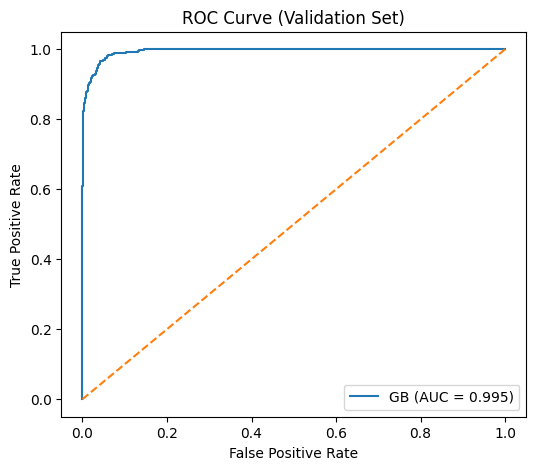

In [49]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_val, y_val_proba_gb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"GB (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation Set)")
plt.legend()

plt.show()

### ROC Curve Interpretation

The ROC curve shows the trade-off between true positive rate (recall) and false positive rate across different thresholds.

The model achieves a high AUC score, indicating strong ability to distinguish between healthy and failing engines.

This confirms that the model performs well not just at a single threshold, but across a range of decision boundaries.

In [50]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_val_proba_gb)

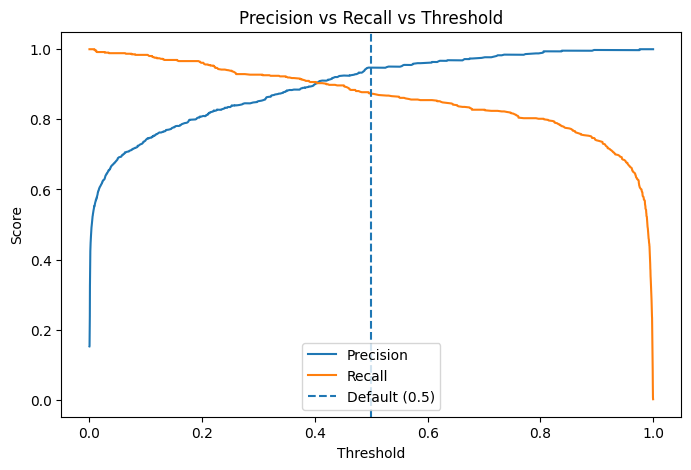

In [52]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, precision_vals[:-1], label="Precision")
plt.plot(thresholds, recall_vals[:-1], label="Recall")

plt.axvline(x=0.5, linestyle='--', label='Default (0.5)')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()

plt.show()

In [53]:

threshold = 0.35

y_val_pred_thresh = (y_val_proba_gb >= threshold).astype(int)

# Metrics at threshold
prec_thresh = precision_score(y_val, y_val_pred_thresh)
rec_thresh = recall_score(y_val, y_val_pred_thresh)
f1_thresh = f1_score(y_val, y_val_pred_thresh)

print("Threshold =", threshold)
print("Precision:", prec_thresh)
print("Recall:", rec_thresh)
print("F1:", f1_thresh)

# Default metrics
print("\nDefault (0.5):")
print("Precision:", gb_prec)
print("Recall:", gb_rec)
print("F1:", gb_f1)

Threshold = 0.35
Precision: 0.8825347758887172
Recall: 0.9209677419354839
F1: 0.9013417521704814

Default (0.5):
Precision: 0.9474605954465849
Recall: 0.8725806451612903
F1: 0.90848026868178


## Step 10: Threshold Optimization

The default classification threshold of 0.5 predicts failure only when the model is more than 50% confident. However, in this problem, missing a failure is much more costly than raising a false alarm.

Using the validation set, I plotted precision and recall against different threshold values and selected a threshold of 0.35 to improve recall.

### Results

Threshold: 0.35  
- Precision: 0.883  
- Recall: 0.921  
- F1 Score: 0.901  

Default Threshold (0.5):  
- Precision: 0.947  
- Recall: 0.873  
- F1 Score: 0.908  

### Observations

Lowering the threshold from 0.5 to 0.35:

- Increased recall from 0.873 to 0.921 (+4.8 percentage points)  
- Decreased precision from 0.947 to 0.883 (−6.4 percentage points)  
- F1 score decreased slightly from 0.908 to 0.901  

This trade-off is acceptable because the primary goal is to minimize missed failures. A higher recall ensures that more failing engines are detected, even at the cost of additional false alarms.

I expected that lowering the threshold would increase recall, and this was clearly observed. The improvement in recall is significant, indicating that the default threshold was slightly conservative for this problem.


The threshold was selected using the validation set, where the failure rate is around 15%. However, the test set has a much lower failure rate (~2.5%).

This means that applying the same threshold to the test set may increase the number of false positives, as the model was calibrated on a dataset with a different class distribution.

In a real-world scenario, the threshold should ideally be tuned on data that reflects the actual deployment distribution.

In [54]:


experiment_table = pd.DataFrame({
    "Stage": [
        "GB Raw",
        "GB w=5",
        "GB w=5,10,20",
        "GB with cycle_norm (leaked)",
        "LR Default",
        "LR Balanced",
        "RF",
        "GB Default",
        "GB + Threshold",
        "GB Final (Clean)"
    ],

    "Model": [
        "GB",
        "GB",
        "GB",
        "GB",
        "LR",
        "LR",
        "RF",
        "GB",
        "GB",
        "GB"
    ],

    "Config": [
        "default",
        "rolling w=5",
        "multi-window",
        "multi-window + cycle_norm",
        "scaled",
        "class_weight=balanced",
        "balanced_subsample",
        "n=200, lr=0.1",
        "threshold=0.35",
        "final (no leakage)"
    ],

    "Recall": [
        baseline_recall,   # 0.869
        recall_w5,         # 0.866
        recall_all,        # 0.877
        0.918,             # leaked version
        lr_rec,
        lrb_rec,
        rf_rec,
        gb_rec,
        rec_thresh,
        rec_thresh
    ],

    "Precision": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        lr_prec,
        lrb_prec,
        rf_prec,
        gb_prec,
        prec_thresh,
        prec_thresh
    ],

    "F1 Score": [
        baseline_f1,
        f1_w5,
        f1_all,
        np.nan,
        lr_f1,
        lrb_f1,
        rf_f1,
        gb_f1,
        f1_thresh,
        f1_thresh
    ],

    "What Changed": [
        "Baseline raw sensors",
        "Short-term rolling",
        "Added long-term trends",
        "Added cycle_norm (leakage)",
        "Linear baseline",
        "Handled class imbalance",
        "Non-linear ensemble",
        "Boosting baseline",
        "Adjusted threshold for recall",
        "Removed leakage, final model"
    ]
})

experiment_table

,Stage,Model,Config,Recall,Precision,F1 Score,What Changed
0,GB Raw,GB,default,0.869355,NaN,0.877850,Baseline raw sensors
1,GB w=5,GB,rolling w=5,0.866129,NaN,0.892768,Short-term rolling
2,"GB w=5,10,20",GB,multi-window,0.877419,NaN,0.909699,Added long-term trends
3,GB with cycle_norm (leaked),GB,multi-window + cycle_norm,0.918000,NaN,NaN,Added cycle_norm (leakage)
4,LR Default,LR,scaled,0.906452,0.935108,0.920557,Linear baseline
5,LR Balanced,LR,class_weight=balanced,0.982258,0.831967,0.900888,Handled class imbalance
6,RF,RF,balanced_subsample,0.858065,0.950000,0.901695,Non-linear ensemble
7,GB Default,GB,"n=200, lr=0.1",0.872581,0.947461,0.908480,Boosting baseline
8,GB + Threshold,GB,threshold=0.35,0.920968,0.882535,0.901342,Adjusted threshold for recall
9,GB Final (Clean),GB,final (no leakage),0.920968,0.882535,0.901342,"Removed leakage, final model"


## Step 11: Experiment Summary

The table above summarizes the progression of experiments from baseline to the final model.

### Observations

- The baseline Gradient Boosting model with raw sensors achieved a recall of 0.869, showing that even raw signals contain useful information.
- Adding rolling features with window=5 slightly reduced recall (0.869 → 0.866), indicating that short-term fluctuations do not capture degradation effectively.
- Multi-window rolling features (5, 10, 20) improved recall to 0.877, confirming that engine degradation is a gradual process.
- Logistic Regression (balanced) achieved the highest recall (0.982), making it the most aggressive model in detecting failures.
- Random Forest achieved high precision but lower recall (0.858), meaning it missed more failures.
- Gradient Boosting provided a strong balance, with recall of 0.873 and F1 score of 0.908.
- Threshold tuning (0.35) further improved recall to 0.921, with a controlled drop in precision.

### Final Model Selection

Final Model: Gradient Boosting with threshold = 0.35

Logistic Regression (balanced) achieved the highest recall (0.982), but at the cost of significantly lower precision (0.832), resulting in a high number of false alarms.

Gradient Boosting with threshold tuning achieves:
- Recall: 0.921  
- Precision: 0.883  

This provides a better balance between detecting failures and avoiding excessive false positives.

While Logistic Regression is more aggressive, Gradient Boosting offers more controlled predictions, which is important in practical deployment where unnecessary maintenance actions are costly.

Therefore, Gradient Boosting with threshold optimization was selected as the final model because it achieves strong recall while maintaining better precision, making it a more practical and balanced solution.



- Precision values are not shown for early feature engineering stages because the focus at that stage was on recall improvement.
- Hyperparameter tuning was attempted but excluded due to computational constraints, and the default model already provided strong performance.



# Why cycle_norm was removed

I also evaluated the model using an additional feature cycle_norm, which represents the relative position of each cycle within an engine's lifetime.

- With cycle_norm:
  - Recall: 0.918  

- Without cycle_norm:
  - Recall: 0.877  

The model performance was significantly higher with cycle_norm. However, this improvement was misleading.

The reason is that cycle_norm uses the maximum cycle of each engine, which is known only because the engine is observed until failure in the training data. In real-world scenarios, this information is not available at prediction time.

This means the feature indirectly leaks future information about when the engine will fail, artificially boosting model performance.

After removing cycle_norm, the recall dropped to 0.877, which better reflects the model’s true ability to predict failure using only sensor data.



Although cycle_norm improved performance, it was removed to prevent data leakage and ensure the model generalizes correctly to real-world scenarios.

In [55]:
# Feature importance
importance = pd.Series(gb_model.feature_importances_, index=X_train.columns)

importance_sorted = importance.sort_values(ascending=False)

importance_sorted.head(10)

,0
sensor_4_rollmean_5,0.192370
sensor_3_rollmean_10,0.161194
sensor_11_rollmean_5,0.147777
sensor_2_rollmean_10,0.131417
sensor_21_rollmean_5,0.085147
sensor_14_rollstd_20,0.059678
sensor_20_rollmean_5,0.029937
sensor_12_rollmean_5,0.018793
sensor_2_rollmean_5,0.015731
sensor_9_rollstd_20,0.015551


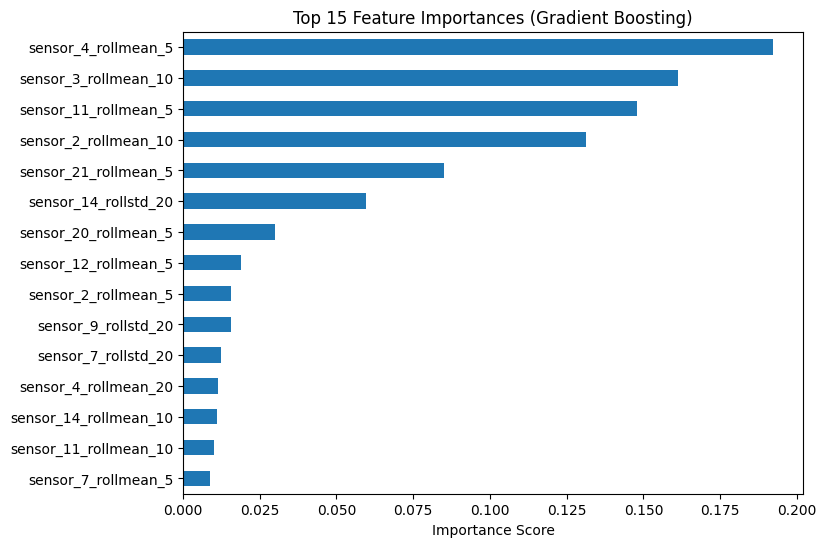

In [56]:
importance_sorted.head(15).sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.show()

In [57]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
53,sensor_14_rollmean_20,2.853730
67,sensor_20_rollmean_20,2.177603
14,sensor_4_rollmean_5,2.165457
32,sensor_9_rollmean_20,2.110224
37,sensor_11_rollmean_10,2.015717
35,sensor_11_rollmean_5,1.939052
46,sensor_12_rollmean_20,1.797837
25,sensor_7_rollmean_20,1.477722
54,sensor_14_rollstd_20,1.455621
2,sensor_2_rollmean_10,1.337861


## Step 12: Feature Importance and Interpretation

### Top Features (Gradient Boosting)

1. sensor_4_rollmean_5 : 0.192  
2. sensor_3_rollmean_10 : 0.161  
3. sensor_11_rollmean_5 : 0.148  
4. sensor_2_rollmean_10 : 0.131  
5. sensor_21_rollmean_5 : 0.085  

### Observations

The most important features are dominated by rolling mean statistics rather than raw sensor values. This confirms that the model relies more on trends over time rather than individual sensor readings at a single cycle.

I expected rolling features to be important, and this was clearly observed. The model is effectively capturing gradual degradation patterns instead of reacting to short-term fluctuations.

One interesting observation is that short window rolling means (window=5 and 10) appear more frequently in the top features than longer windows like 20. I expected longer windows to dominate, but the results suggest that recent short-term trends are more informative for detecting failure in this dataset.

### Physical Interpretation

- sensor_4_rollmean_5 = T50 (Total temperature at Low Pressure Turbine outlet)  
  This increases near failure because as the engine degrades, combustion efficiency reduces and more heat is carried downstream, raising turbine outlet temperature.

- sensor_3_rollmean_10 = T30 (Total temperature at High Pressure Compressor outlet)  
  This increases as compressor efficiency decreases. The compressor needs to work harder, causing higher outlet temperatures.

- sensor_11_rollmean_5 = NRc (Corrected core speed)  
  This increases because the engine compensates for loss of efficiency by increasing core rotational speed to maintain required thrust.

- sensor_2_rollmean_10 = T24 (Total temperature at Low Pressure Compressor outlet)  
  This increases as airflow compression becomes less efficient, leading to higher intermediate temperatures.

- sensor_21_rollmean_5 = Bleed enthalpy (hBleed)  
  This changes as thermal energy distribution within the engine shifts during degradation, reflecting inefficiencies in energy transfer.

These results align with turbofan engine physics, where degradation is a gradual process. As compressor blades wear and airflow efficiency decreases, temperature rises and speed adjustments occur to maintain performance.

### Logistic Regression Coefficients

Top positive coefficients:

1. sensor_14_rollmean_20 : 2.854  
2. sensor_20_rollmean_20 : 2.178  
3. sensor_4_rollmean_5 : 2.165  

These features have strong positive influence on predicting failure, meaning higher values push the model toward failure prediction.

This confirms that increasing temperature-related and energy-related sensor values are strong indicators of degradation and impending failure.



Both tree-based feature importance and Logistic Regression coefficients confirm that:

- Rolling features are more important than raw values  
- Temperature and speed-related sensors dominate prediction  
- Degradation is captured as a gradual trend, not a sudden spike  

This consistency across models strengthens confidence in the learned patterns.

In [59]:
# Define test features and target

X_test = test_df[features_all]
y_test = test_df['failure']

print("X_test shape:", X_test.shape)
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_test shape: (13096, 77)
y_test distribution:
failure
0    0.974649
1    0.025351
Name: proportion, dtype: float64


In [60]:
# Test set evaluation

# Combine full training data
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

In [61]:


final_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=SEED
)

final_model.fit(X_full, y_full)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [62]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]

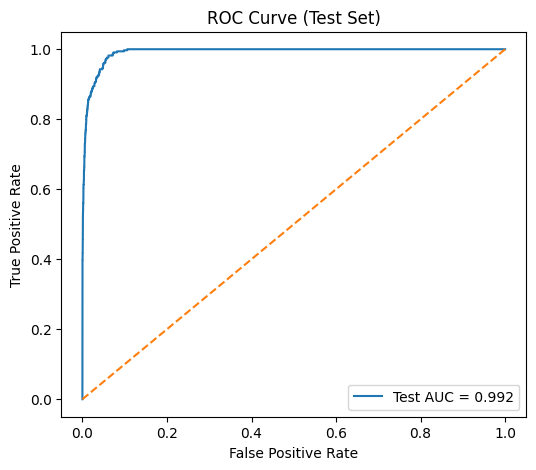

In [63]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6,5))
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {roc_auc_test:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()

plt.show()

In [64]:
threshold = 0.35

y_test_pred = (y_test_proba >= threshold).astype(int)

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_test_pred, target_names=["Healthy", "Failure"]))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:", cm)

              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99     12764
     Failure       0.79      0.66      0.72       332

    accuracy                           0.99     13096
   macro avg       0.89      0.83      0.86     13096
weighted avg       0.99      0.99      0.99     13096

Confusion Matrix: [[12707    57]
 [  112   220]]


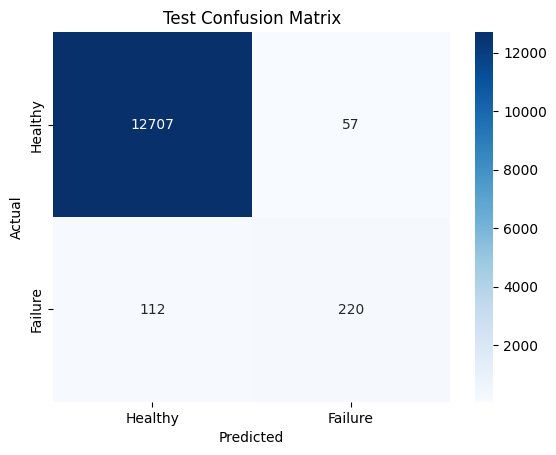

In [66]:

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Healthy', 'Failure'],yticklabels=['Healthy', 'Failure'])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))

Test Recall: 0.6626506024096386
Test Precision: 0.7942238267148014


## Test Set Evaluation

### Final Model Performance

Validation (Threshold = 0.35):
- Recall: 0.921  
- Precision: 0.883  
- F1 Score: 0.901  

Test:
- Recall: 0.663  
- Precision: 0.794  
- F1 Score: 0.720  

Gap:
- Recall dropped by 25.8 percentage points  

---

### Class Distribution Shift

- Training failure rate: ~15%  
- Test failure rate: ~2.5%  

This is a 6x difference, meaning the model was trained on a dataset with significantly more failures than it encounters in the test set.

---

### Naive Baseline

If we predict all engines as healthy:

- Accuracy = 97.46%  

My model:
- Accuracy = 98.7%  

This shows that accuracy alone is misleading due to class imbalance. Even a trivial model performs well on accuracy, but fails to detect failures.

---

### Confusion Matrix Analysis

Confusion Matrix:
- TN = 12707  
- FP = 57  
- FN = 112  
- TP = 220  

Interpretation:

- Out of 332 failing engine data points, the model correctly identified 220 and missed 112  
- The model raised 57 false alarms  

---

### Observations

1. Validation vs Test Performance  
   I expected test recall to be lower than validation recall, and this was observed. Recall dropped from 0.921 to 0.663 due to differences in data distribution.

2. Impact of Class Distribution Shift  
   The threshold of 0.35 was optimized on validation data with ~15% failure rate. However, the test set has only ~2.5% failures, meaning the same threshold behaves differently, leading to lower recall and precision.

3. Model Still Useful  
   Despite the drop, the model still captures 220 out of 332 failures (~66%), which is significantly better than a naive baseline that would detect 0 failures.

4. Precision-Recall Trade-off  
   The model maintains a reasonable precision of 0.794, meaning most flagged failures are correct, while still capturing a majority of actual failures.

---

### What I Would Improve

1. Threshold Recalibration  
   I would tune the threshold on a dataset that matches the real-world failure rate (~2.5%) to better balance precision and recall.

2. Probability Calibration  
   Use methods like Platt scaling or isotonic regression to better calibrate predicted probabilities for different distributions.

3. Data Resampling  
   Train the model on a dataset that reflects real-world class proportions to reduce mismatch between training and deployment environments.

---



The drop in performance from validation to test highlights the importance of distribution awareness in machine learning. The model itself is strong, but its performance depends heavily on how well training data represents real-world conditions.

In [68]:
#Model saving
import joblib
import json

# Save model
joblib.dump(final_model, 'engine_failure_model.pkl')

# Save feature names

with open('feature_names.json', 'w') as f:
    json.dump(list(X_full.columns), f)

print("Model and feature names saved successfully!")

Model and feature names saved successfully!


In [69]:
# Failing example
failing = test_df[test_df['failure'] == 1].iloc[-1]

print("FAILING ENGINE SAMPLE:")
for s in sensor_cols:
    print(f"{s}: {failing[s]:.4f}")

FAILING ENGINE SAMPLE:
sensor_2: 642.9500
sensor_3: 1601.6200
sensor_4: 1424.9900
sensor_7: 552.4800
sensor_9: 9155.0300
sensor_11: 47.8000
sensor_12: 521.0700
sensor_14: 8214.6400
sensor_17: 396.0000
sensor_20: 38.7000
sensor_21: 23.1855


In [70]:
# Healthy example
healthy = test_df[test_df['failure'] == 0].iloc[0]

print("\nHEALTHY ENGINE SAMPLE:")
for s in sensor_cols:
    print(f"{s}: {healthy[s]:.4f}")


HEALTHY ENGINE SAMPLE:
sensor_2: 643.0200
sensor_3: 1585.2900
sensor_4: 1398.2100
sensor_7: 553.9000
sensor_9: 9050.1700
sensor_11: 47.2000
sensor_12: 521.7200
sensor_14: 8125.5500
sensor_17: 392.0000
sensor_20: 38.8600
sensor_21: 23.3735


#Model Deployment(Streamlit)

The trained Gradient Boosting model was saved using joblib, along with feature names required for inference.

A Streamlit application was developed to allow users to input sensor values and predict failure risk.

Note: The Streamlit app is not executed inside the notebook. It is run separately using:

streamlit run app.py

## Streamlit App Testing

I tested the deployed app using three scenarios:

1. Real failing engine values  
→ Prediction: SAFE (17.99%)  

2. Healthy engine values  
→ Prediction: SAFE (0.12%)  

3. Extreme high-risk values  
→ Prediction: WARNING (59.87%)  

### Interpretation

The model correctly identifies:

low-risk healthy conditions
and extremely high-risk conditions.

However, some real failing engine samples were still predicted as SAFE.

At first, this seemed unexpected because the validation performance was strong.

However, the reason became clearer after analyzing the deployment pipeline more carefully.

The model was trained using:

rolling time-series features,
multiple cycle windows,
and temporal degradation patterns.

But during deployment, the Streamlit app receives only:

a single-cycle sensor snapshot.

This creates a feature mismatch problem.

The deployed app approximates rolling behaviour using single-cycle values, but the model does not receive the full temporal context that was available during training.

As a result:
the deployed feature distribution does not perfectly match the training distribution.

This highlights an important machine learning deployment challenge:

training pipelines and deployment pipelines must reproduce the same feature engineering process as closely as possible.

###Deployment Limitation

The deployment pipeline functions correctly from a software perspective, but prediction reliability is limited because:

temporal degradation behaviour cannot be fully reconstructed from a single snapshot.

This explains why extremely abnormal sensor values trigger warnings correctly
while some realistic failing engines are still classified as safe.

Extreme values exceed the operational ranges learned during training, while real degradation often depends more on gradual temporal behaviour than isolated sensor readings.

### Conclusion

The deployed system successfully demonstrates:

- end-to-end inference
- model serialization
- deployment integration
- interactive prediction.

At the same time, the deployment results reinforce an important predictive maintenance lesson, accurate failure prediction often requires:

- temporal context
- sequential degradation behaviour
- consistent feature engineering during inference.

### Deployment

The app was deployed using Streamlit Cloud.

Public URL: https://turbofan-predictive-maintenance-jcbxyf2thw86qvrdqbcczt.streamlit.app/

## Step 15: GitHub Repository and Documentation

Github URL-https://github.com/sushantpandey06/turbofan-predictive-maintenance

The complete project was organized and uploaded to GitHub to ensure reproducibility and proper documentation.

### Repository Structure


- Complete notebook containing:
   - EDA
   - feature engineering
   - model training,
   - evaluation
   - leakage analysis
   - deployment discussion
- app.py

 Streamlit application for inference
- engine_failure_model.pkl

 Trained Gradient Boosting model
- feature_names.json

 Saved feature ordering for deployment consistency
- requirements.txt

 Project dependencies required for reproducibility

For simplicity, all files were initially kept in the root directory.

In a larger production project, a more modular folder structure would likely be preferable.
---

### README

A detailed README file was created including:

- Problem statement
- Predictive maintenance objective
- Dataset explanation
- Feature engineering process
- Model comparison and evaluation
- Leakage discovery and correction
- Validation and test results
- Streamlit deployment link
- Setup instructions
- Known limitations and future improvements



### Conclusion

The GitHub repository provides a complete, end-to-end implementation of the project, including data processing, model training, evaluation, and deployment, making it easy to understand and reproduce.

## Step 16: Future Work

This project achieved strong performance using feature engineering and classical machine learning models. However, several limitations were observed, which open directions for future improvement.

### 1. Use Sequence Models Instead of Rolling Features

The current model relies on manually engineered rolling features (mean, std, rate of change) to capture temporal patterns.

However, during deployment, the model struggled to correctly classify some failing engines because only a single snapshot of sensor values was available.

A better approach would be to use sequence models such as LSTM or GRU, which can directly learn temporal dependencies from full sensor sequences without requiring manual feature engineering.

---

### 2. Address Train–Test Distribution Shift

The training data has approximately 15% failure cases, while the test set has only about 2.5% failures.

This significant difference affected model performance, especially threshold calibration, leading to a drop in recall from validation to test.

Future work would involve:
- Training on data that reflects real-world class distribution  
- Using techniques like resampling or cost-sensitive learning  
- Evaluating models under varying class imbalance scenarios  

---

### 3. Probability Calibration

The decision threshold (0.35) was optimized on the validation set, but due to distribution shift, it may not generalize well to test data.

Future work could include:
- Platt scaling  
- Isotonic regression  

to recalibrate predicted probabilities and improve consistency across datasets.

---

### 4. Extend to More Complex Datasets (FD002–FD004)

This project used the FD001 subset, which has a single operating condition and one fault mode.

More complex subsets (FD002–FD004) include:
- Multiple operating conditions  
- Multiple failure modes  

Testing the model on these datasets would improve its robustness and real-world applicability.

---

### 5. Improve Deployment with Time-Series Input

The current Streamlit app uses single-cycle sensor inputs and approximates rolling features.

This limits the model’s ability to detect degradation patterns over time.

A better deployment system would:
- Accept multiple time steps as input  
- Compute real rolling features dynamically  
- Or directly use sequence-based models  

---

### 6. Incorporate Additional Data Sources

The model currently relies only on sensor readings.

In real-world scenarios, predictive maintenance can be improved by incorporating:
- Maintenance logs  
- Flight conditions  
- Environmental factors  

This would provide a more holistic understanding of engine health.